# Gráficas de `ins_data.csv`

Posición y orientación del INS.
Columnas: `date`, `ref_id`, `pos_x`, `pos_y`, `pos_z`, `yaw`.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('ins_data_prueba_11.csv', parse_dates=['date'])
print(f"{len(df)} filas | {df['date'].min()} -> {df['date'].max()}")
print('ref_id:', df['ref_id'].unique())
df.head()

1924 filas | 2026-07-31 11:48:37 -> 2026-07-31 11:51:50
ref_id: [10000]


,date,ref_id,pos_x,pos_y,pos_z,yaw
0,2026-07-31 11:48:37,10000,0,0,0,1
1,2026-07-31 11:48:37,10000,0,0,0,1
2,2026-07-31 11:48:37,10000,0,0,0,1
3,2026-07-31 11:48:37,10000,0,0,0,1
4,2026-07-31 11:48:37,10000,0,0,0,1


In [7]:
df[['pos_x', 'pos_y', 'pos_z', 'yaw']].describe()

,pos_x,pos_y,pos_z,yaw
count,1924.000000,1924.000000,1924.000000,1924.000000
mean,107541.550936,112005.894491,-890.938150,3644.685031
std,101069.297718,163781.264981,850.087864,4237.500160
min,-4479.000000,-5.000000,-2757.000000,1.000000
25%,0.000000,0.000000,-1517.250000,5.000000
50%,102492.500000,112.500000,-1116.500000,6.500000
75%,212076.750000,216101.750000,0.000000,8610.000000
max,233274.000000,527023.000000,64.000000,8704.000000


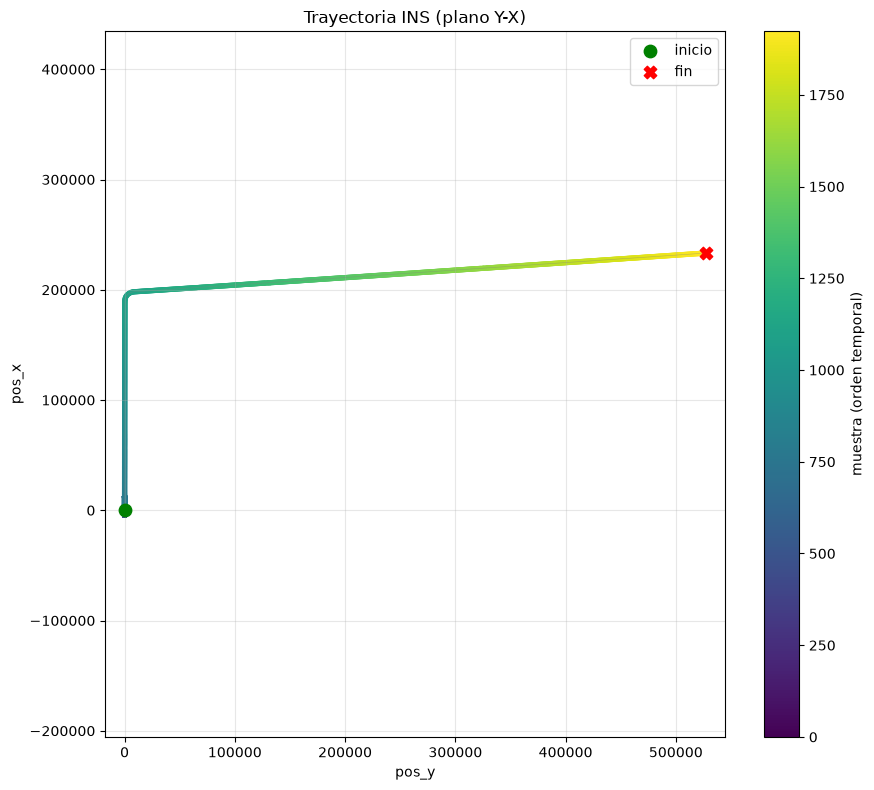

In [8]:
# Trayectoria en el plano X-Y (coloreada por tiempo)
fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(df['pos_y'], df['pos_x'], c=df.index, cmap='viridis', s=8)
ax.plot(df['pos_y'], df['pos_x'], color='gray', linewidth=0.4, alpha=0.5)
ax.scatter(df['pos_y'].iloc[0], df['pos_x'].iloc[0], color='green', s=80, marker='o', label='inicio', zorder=5)
ax.scatter(df['pos_y'].iloc[-1], df['pos_x'].iloc[-1], color='red', s=80, marker='X', label='fin', zorder=5)
ax.set_xlabel('pos_y')
ax.set_ylabel('pos_x')
ax.set_title('Trayectoria INS (plano Y-X)')
ax.set_aspect('equal', adjustable='datalim')
ax.legend()
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, label='muestra (orden temporal)')
plt.tight_layout()
plt.show()

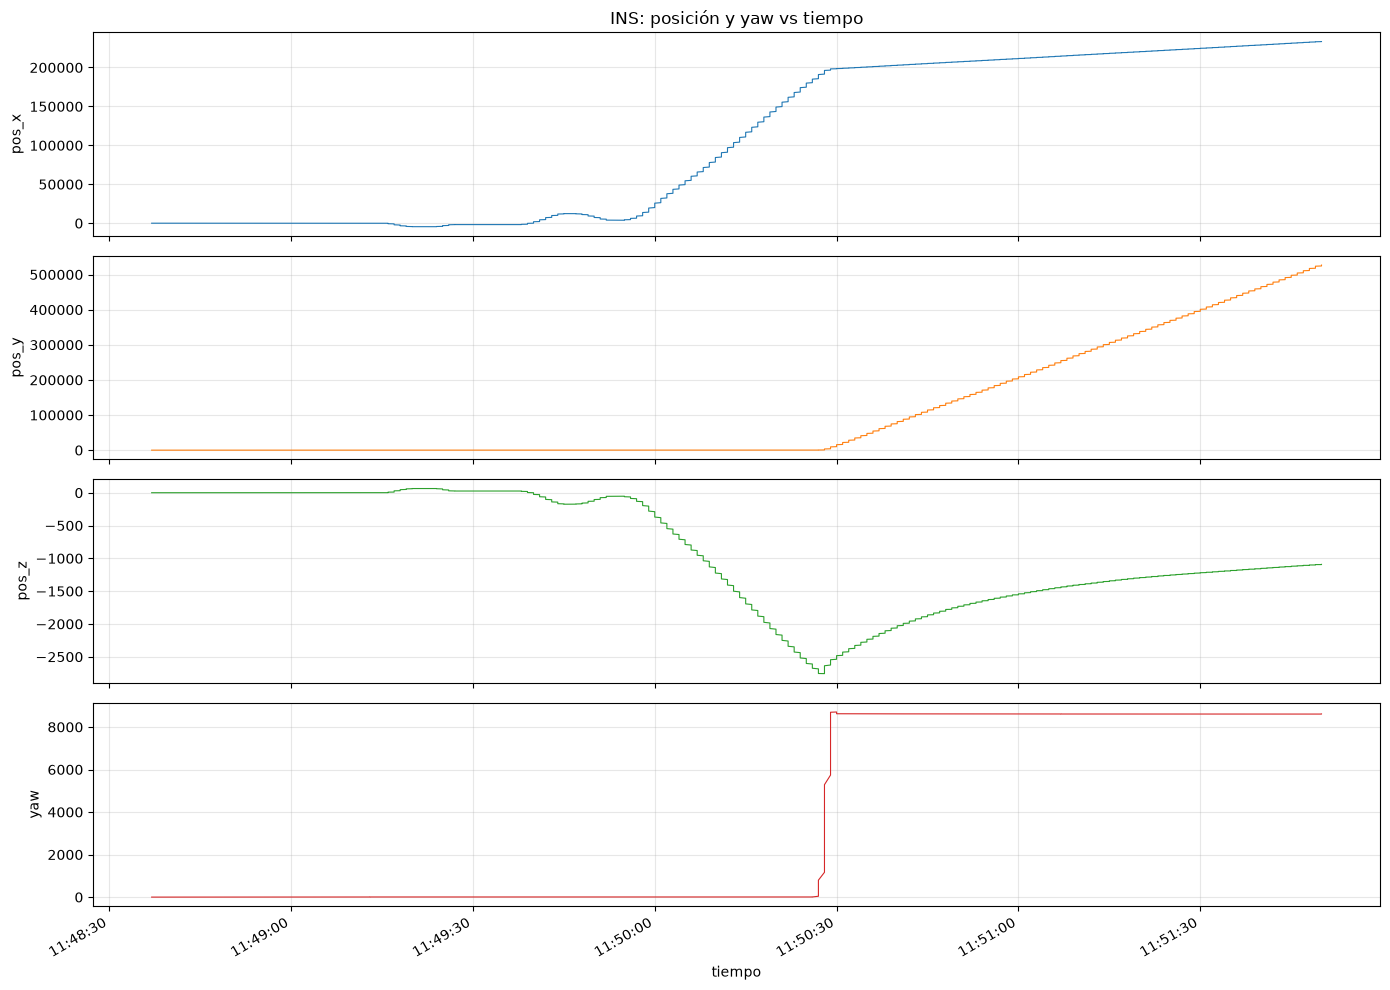

In [9]:
# Series temporales de cada componente
cols = ['pos_x', 'pos_y', 'pos_z', 'yaw']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
fig, axes = plt.subplots(len(cols), 1, figsize=(14, 10), sharex=True)
for ax, col, c in zip(axes, cols, colors):
    ax.plot(df['date'], df[col], color=c, linewidth=0.8)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
axes[0].set_title('INS: posición y yaw vs tiempo')
axes[-1].set_xlabel('tiempo')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

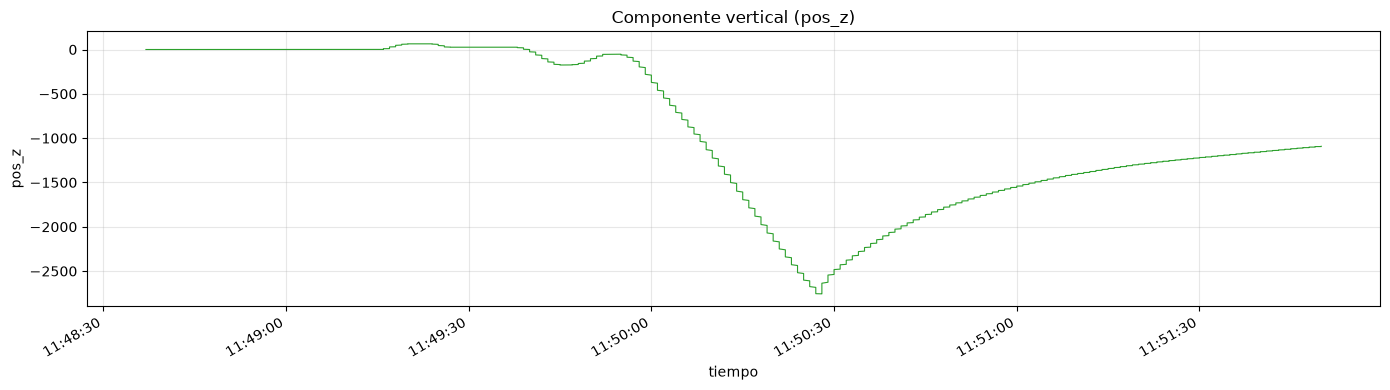

In [10]:
# Altura (pos_z) vs tiempo, en detalle
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['pos_z'], color='tab:green', linewidth=0.8)
ax.set_xlabel('tiempo')
ax.set_ylabel('pos_z')
ax.set_title('Componente vertical (pos_z)')
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()